Describe, gestine null, pair plot, control outlier, grafici, matrice corrispondenze, grafici corrispondenze, <br> rifare corrispondenze senza outlier, features combinate derivate, grafici, raggruppare features continue (fasce di prezzo da prezzo)

In [140]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

#caricamento del file
file_path = "Cars Datasets 2025.csv"
df = pd.read_csv(file_path, encoding='latin-1')

print("\n=====INFO TABELLA=====\n")
df.info()

print("\n=====DESCRIBE TABELLA=====\n")
df.describe()


=====INFO TABELLA=====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1217 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB

=====DESCRIBE TABELLA=====



,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
count,1218,1218,1218,1215,1218,1218,1212,1218,1218,1218,1217
unique,37,1201,356,311,456,114,180,535,23,19,263
top,Nissan,Macan T,I4,"2,000 cc",355 hp,250 km/h,6.5 sec,"$35,000",Petrol,5,400 Nm
freq,149,2,64,31,23,145,45,36,871,692,72


In [ ]:
print(df["Fuel Types"].unique())
print("=============")
conteggi = df['Fuel Types'].value_counts()
print(conteggi)
df.nunique()

['plug in hyrbrid' 'Petrol' 'Diesel' 'Hybrid' 'Electric' 'Petrol/Diesel'
 'Plug-in Hybrid' 'Petrol/AWD' 'Petrol/Hybrid' 'Hydrogen' 'Diesel/Petrol'
 'Petrol/EV' 'Hybrid/Electric' 'Petrol, Hybrid' 'Petrol, Diesel'
 'Hybrid (Petrol)' 'CNG/Petrol' 'Hybrid/Petrol' 'Diesel Hybrid'
 'Petrol (Hybrid)' 'Hybrid (Gas + Electric)' 'Gas / Hybrid'
 'Hybrid / Plug-in']
Fuel Types
Petrol                     871
Diesel                     106
Electric                    97
Hybrid                      79
Petrol/Diesel               16
Petrol/Hybrid               16
Plug-in Hybrid               5
Diesel/Petrol                4
Hybrid (Petrol)              4
Hydrogen                     3
Petrol, Diesel               3
Petrol/AWD                   2
Petrol, Hybrid               2
Hybrid (Gas + Electric)      1
plug in hyrbrid              1
Gas / Hybrid                 1
Diesel Hybrid                1
Petrol (Hybrid)              1
Petrol/EV                    1
Hybrid/Petrol                1
CNG/Petrol  

Company Names                  37
Cars Names                   1201
Engines                       356
CC/Battery Capacity           311
HorsePower                    456
Total Speed                   114
Performance(0 - 100 )KM/H     180
Cars Prices                   535
Fuel Types                     23
Seats                          19
Torque                        263
dtype: int64

Dall'info risultano 3 valori nulli in CC battery, 6 performance, 1 torque

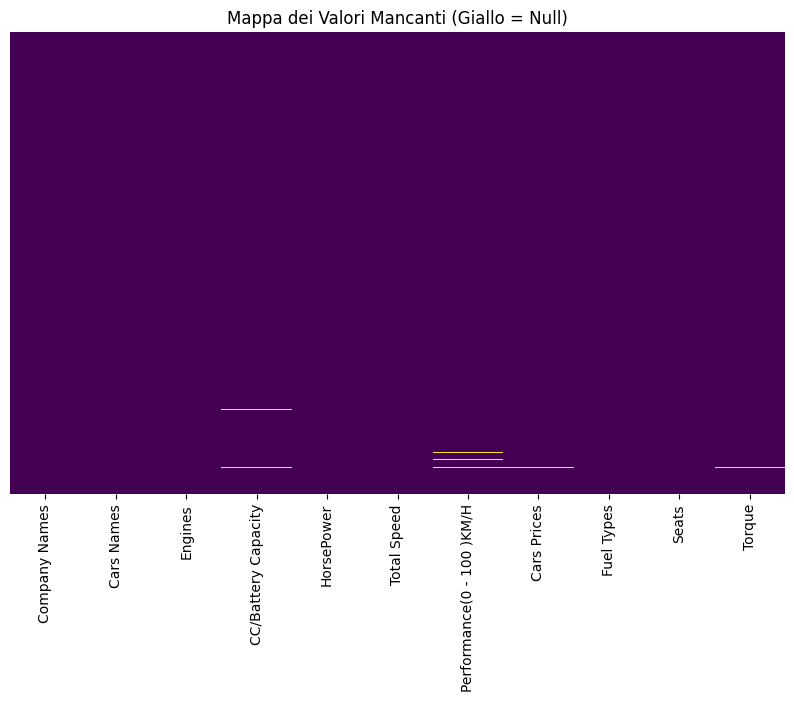

,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Torque
0,3990.0,963.0,340.0,2.5,1.0,800.0
1,6749.0,563.0,250.0,5.3,460.0,900.0
2,1.0,70.0,165.0,10.5,12.0,100.0
3,3.0,630.0,250.0,3.2,161.0,900.0
4,5.0,602.0,320.0,3.6,253.0,560.0
...,...,...,...,...,...,...
1213,2487.0,240.0,180.0,7.6,43.0,239.0
1214,2393.0,326.0,180.0,6.8,50.0,630.0
1215,1987.0,169.0,190.0,8.0,25.0,190.0
1216,1798.0,140.0,180.0,7.9,33.0,190.0


In [142]:
#conversione valori stringa in numeri
def extract_numeric(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    m = re.findall(r"[-+]?\d*\.?\d+", s)
    if not m:
        return np.nan
    return float(m[0])

numeric_cols_raw = [
    "CC/Battery Capacity",
    "HorsePower",
    "Total Speed",
    "Performance(0 - 100 )KM/H",
    "Cars Prices",
    "Torque"
]

for col in numeric_cols_raw:
    if col in df.columns:
        df[col] = df[col].apply(extract_numeric)
        
#visualizzazione dei dati mancanti
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mappa dei Valori Mancanti (Giallo = Null)')
plt.show()

#elenco colonna numeriche
numeric_cols = df.select_dtypes(include=["float", "int"]).columns.tolist()

#rimozione e sostituzione colonne valori nulli essendo di poco conto
df[numeric_cols].fillna(df[numeric_cols].mean())
df[numeric_cols].dropna()

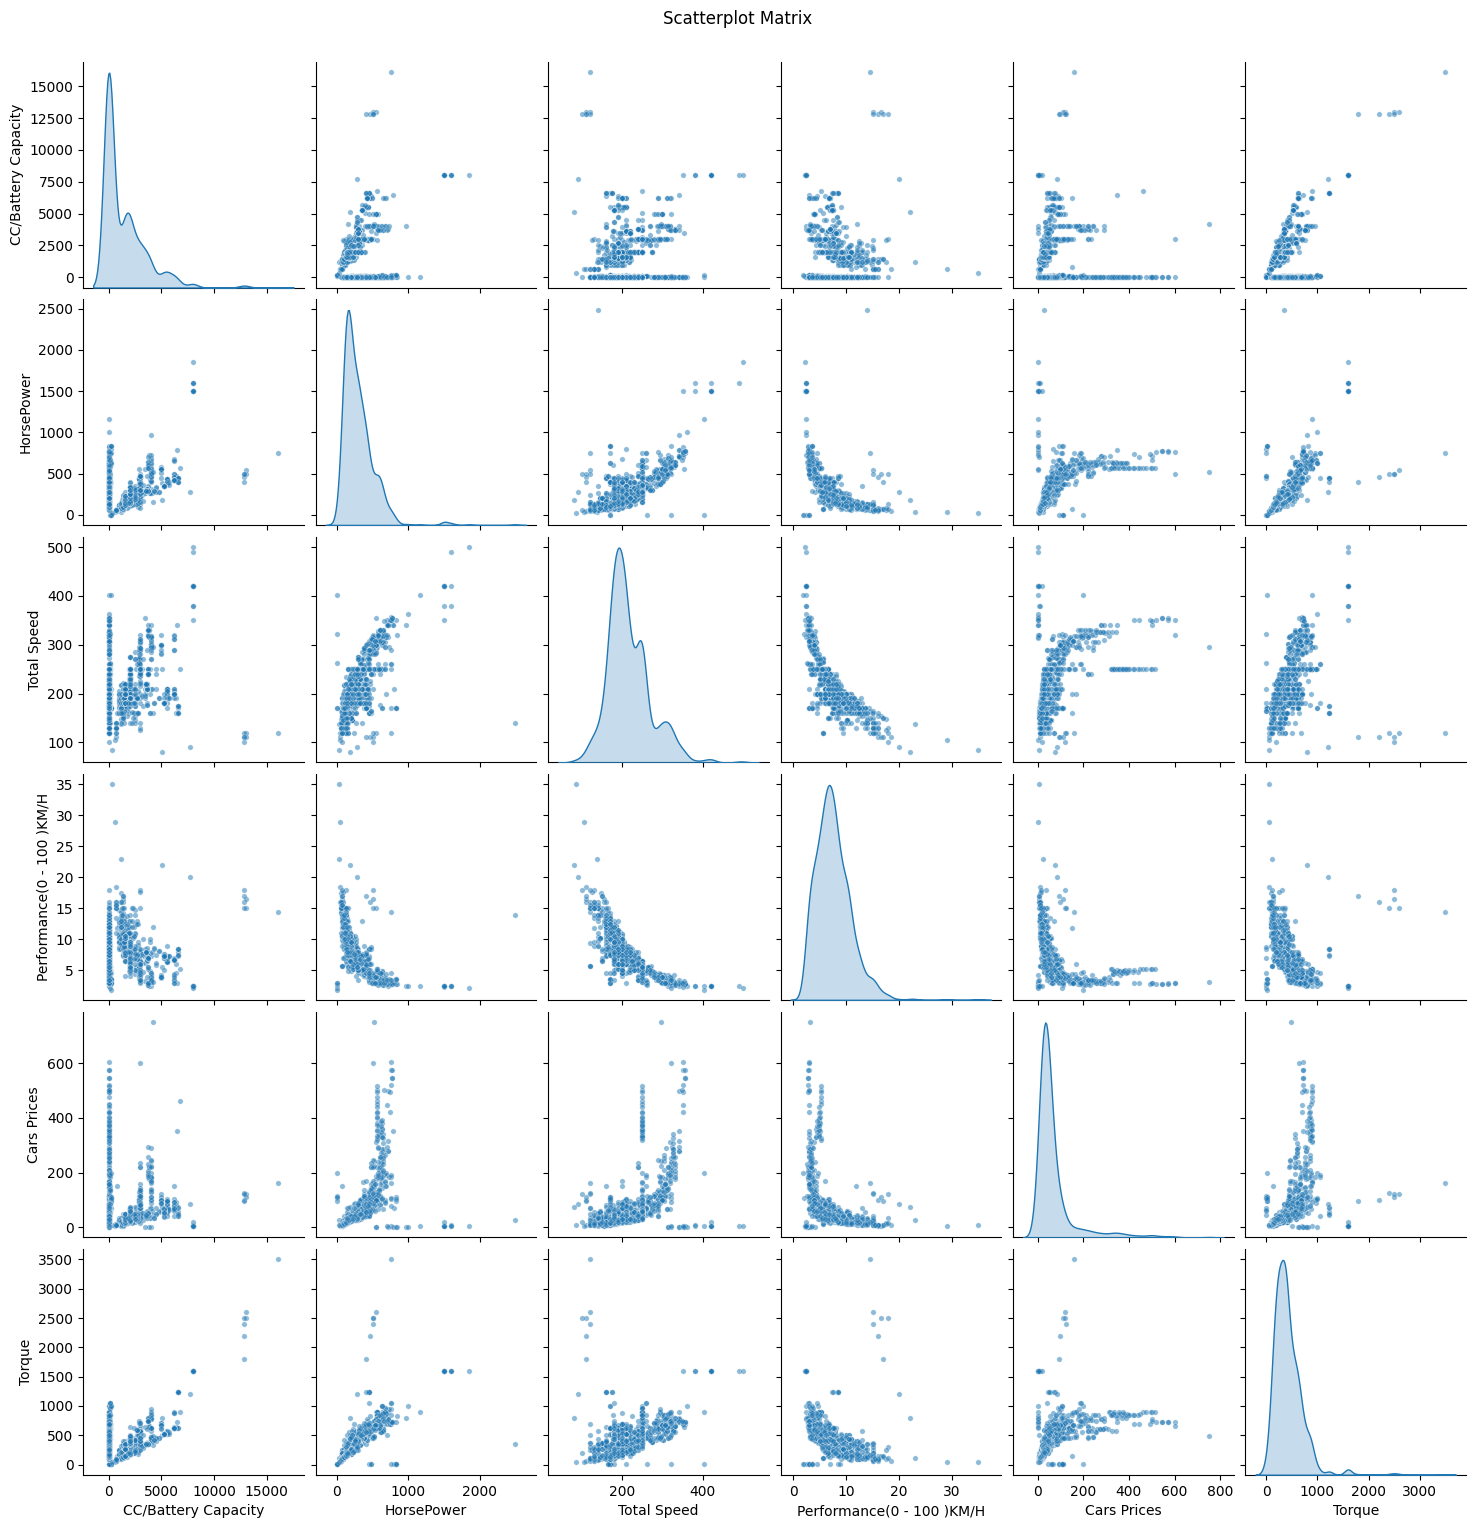

In [143]:
#colonne da mettere come grafico
cols_to_plot = ["CC/Battery Capacity","HorsePower","Total Speed","Performance(0 - 100 )KM/H","Cars Prices", "Torque"]

#grafico scatterplot a matrice
g = sns.pairplot(df[cols_to_plot], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15}, diag_kws={'fill': True}, height=2.5)

g.figure.suptitle('Scatterplot Matrix', y=1.02)
plt.show()


OUTLIERS COUNT:
CC/Battery Capacity 92
HorsePower 22
Total Speed 13
Performance(0 - 100 )KM/H 23
Cars Prices 129
Torque 26

Shape after outlier removal: (925, 11)

CORRELATION WITHOUT OUTLIERS:
                            CC/Battery Capacity  HorsePower  Total Speed  \
CC/Battery Capacity                   1.000000    0.140733     0.260832   
HorsePower                            0.140733    1.000000     0.622842   
Total Speed                           0.260832    0.622842     1.000000   
Performance(0 - 100 )KM/H            -0.110817   -0.772273    -0.778976   
Cars Prices                           0.186784    0.782991     0.577038   
Torque                                0.083969    0.839111     0.502520   

                           Performance(0 - 100 )KM/H  Cars Prices    Torque  
CC/Battery Capacity                        -0.110817     0.186784  0.083969  
HorsePower                                 -0.772273     0.782991  0.839111  
Total Speed                                -

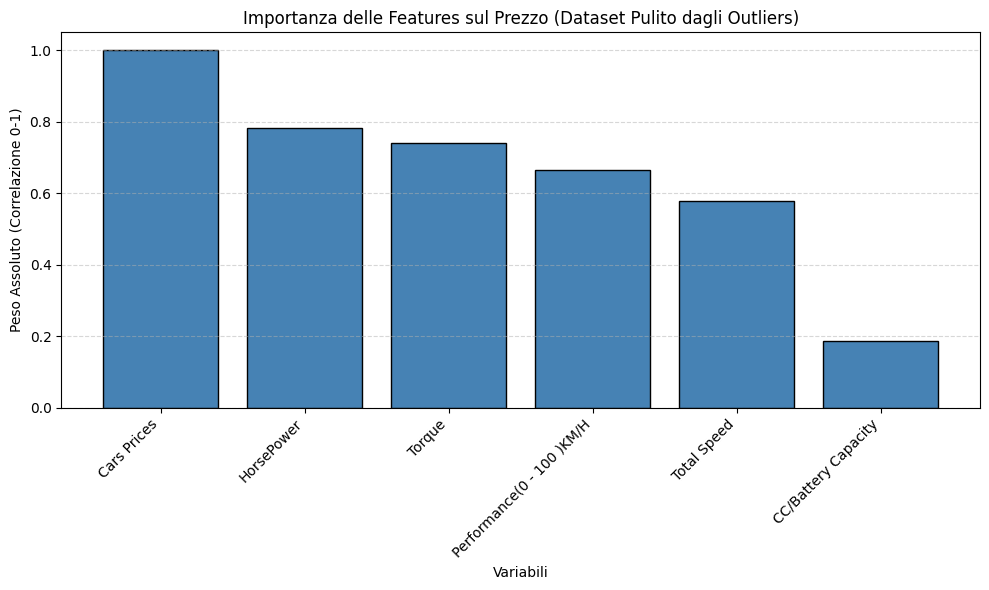

In [144]:
#trova gli outliers
numeric_cols = df.select_dtypes(include=["float", "int"]).columns.tolist()

def find_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return df[(df[col] < low) | (df[col] > high)]

print("\nOUTLIERS COUNT:")
for col in numeric_cols:
    print(col, len(find_outliers(col)))

df_no_out = df.copy()
for col in numeric_cols:
    Q1 = df_no_out[col].quantile(0.25)
    Q3 = df_no_out[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df_no_out = df_no_out[(df_no_out[col] >= low) & (df_no_out[col] <= high)]

print("\nShape after outlier removal:", df_no_out.shape)

corr_no_out = df_no_out[numeric_cols].corr()
corr_price = df_no_out[numeric_cols].corr()["Cars Prices"].abs().sort_values(ascending=False)
print("\nCORRELATION WITHOUT OUTLIERS:\n", corr_no_out)

plt.figure(figsize=(10, 6))
plt.bar(corr_price.index, corr_price.values, color='steelblue', edgecolor='black')

plt.title('Importanza delle Features sul Prezzo (Dataset Pulito dagli Outliers)')
plt.ylabel('Peso Assoluto (Correlazione 0-1)')
plt.xlabel('Variabili')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

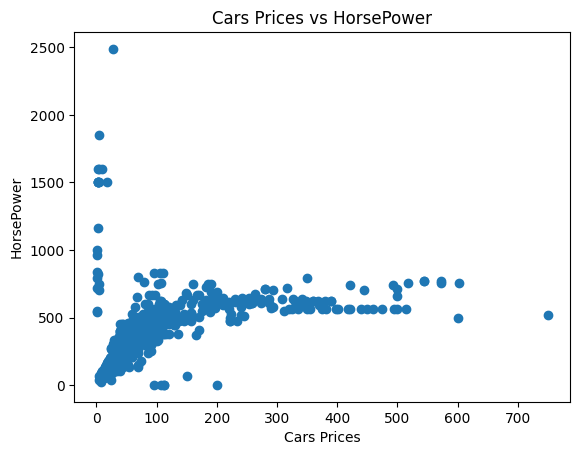

In [145]:
plt.figure()
plt.scatter(df["Cars Prices"], df["HorsePower"])
plt.xlabel("Cars Prices")
plt.ylabel("HorsePower")
plt.title("Cars Prices vs HorsePower")
plt.show()

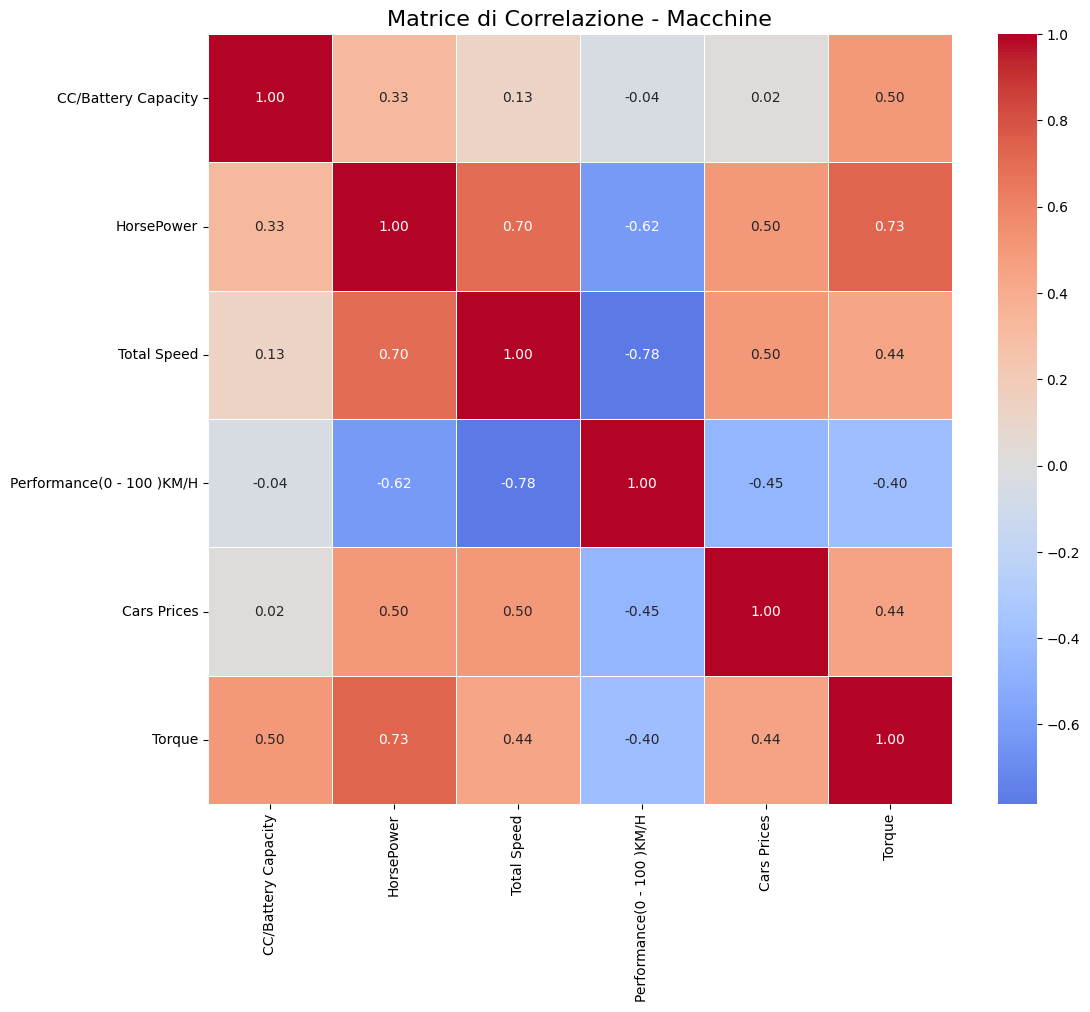

In [146]:
#matrice di correlazione
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    fmt=".2f"
)

plt.title('Matrice di Correlazione - Macchine', fontsize=16)
plt.show()